Este es un dataset que contiene información de comercios con las distintas categorías de ventas que tienen, metros cuadrados, cantidad de días de atención, si tiene envío a domicilio, si tienen scanner, cantidad de empleados, la presencia o ausencia de una categoría, etc

<a id="1"></a> <br>
## Paso 1 : Leyendo y observando la información

In [1]:
# import required libraries for dataframe and visualization

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

# import required libraries for clustering
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import cut_tree

In [2]:
# Levantamos el archivo excel

retail = pd.read_excel('../input/base-censo-comercios/Base Nacional FINAL.xlsx',sheet_name='Base Nacional FINAL')
retail.head()

,Código o nro. de negocio,Tipo de Negocio o Rubro principal,Ubicación,Movimiento o Tránsito en calle principal,Cantidad de cajas,Cantidad de sucursales,Abierto desde,Abierto hasta,Cantidad Días por Semana,Metros cuadrados salón de ventas,...,ALIMENTOS_PREPARADOS,OTROS_ALMACEN,JUGOS_INFUSIONES,VINOS,ALMACEN,COSMETICA_ALTA,HOGAR,LIMPIEZA,COSMETICA_COMUN,Tamaño de localidad
0,2030002,ALMACEN / DESPENSA / FIAMBRERIA,CALLE O AVDA. PRINCIPAL,MUY TRANSITADO,0,0,07:30,23:30,6,6,...,2,6,6,2,24,1,5,9,5,> 100000
1,2040961,ALMACEN / DESPENSA / FIAMBRERIA,BARRIO,MEDIANAMENTE TRANSITADO,0,0,13:00,22:00,6,100,...,1,6,6,2,24,1,0,8,5,> 100000
2,2020802,ALMACEN / DESPENSA / FIAMBRERIA,CALLE O AVDA. PRINCIPAL,MUY TRANSITADO,0,0,07:00,23:00,6,100,...,2,6,6,2,24,5,5,9,5,> 100000
3,2040726,ALMACEN / DESPENSA / FIAMBRERIA,AVENIDA,MUY TRANSITADO,0,0,08:00,23:30,7,100,...,2,2,6,2,17,2,0,5,5,> 100000
4,2040978,ALMACEN / DESPENSA / FIAMBRERIA,AVENIDA,MUY TRANSITADO,0,0,09:00,23:00,7,90,...,4,5,6,2,24,2,1,9,5,> 100000


In [3]:
# observamos la cantidad de variables que tenemos y los registros

retail.shape

(16375, 136)

In [4]:
# df info

retail.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16375 entries, 0 to 16374
Columns: 136 entries, Código o nro. de negocio to Tamaño de localidad
dtypes: int64(127), object(9)
memory usage: 17.0+ MB


In [5]:
# Hacemos una descripción del dataset en general

retail.describe()

,Código o nro. de negocio,Cantidad de cajas,Cantidad Días por Semana,Metros cuadrados salón de ventas,Cantidad de Empleados,Cant. de heladeras verticales para bebidas o lácteos,Cantidad Categorías,Alimentos y Bebidas,Aceites,Aceites Sueltos,...,Café instantáneo,ALIMENTOS_PREPARADOS,OTROS_ALMACEN,JUGOS_INFUSIONES,VINOS,ALMACEN,COSMETICA_ALTA,HOGAR,LIMPIEZA,COSMETICA_COMUN
count,1.637500e+04,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,...,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000
mean,6.040454e+08,0.200489,6.661069,37.486229,2.198046,2.673832,51.320489,25.013863,0.650321,0.009221,...,0.082931,1.103756,4.405557,3.537832,1.238718,12.961160,1.151389,2.205191,5.106443,3.417893
std,3.919649e+08,0.561411,0.473361,49.316533,1.566309,2.709218,27.566445,16.161640,0.476883,0.095587,...,0.275787,1.542499,4.139011,1.606797,0.922483,9.041371,1.729787,2.237768,3.399641,1.789512
min,2.010136e+06,0.000000,6.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.850631e+08,0.000000,6.000000,16.000000,1.000000,1.000000,24.000000,8.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,3.000000,0.000000,1.000000,0.000000,0.000000,1.000000,2.000000
50%,6.160206e+08,0.000000,7.000000,25.000000,2.000000,2.000000,55.000000,29.000000,1.000000,0.000000,...,0.000000,0.000000,3.000000,4.000000,2.000000,18.000000,0.000000,1.000000,7.000000,4.000000
75%,8.092565e+08,0.000000,7.000000,40.000000,2.000000,4.000000,77.000000,40.000000,1.000000,0.000000,...,0.000000,2.000000,8.000000,4.000000,2.000000,20.000000,2.000000,4.000000,8.000000,5.000000
max,1.664016e+09,5.000000,7.000000,900.000000,6.000000,56.000000,100.000000,50.000000,1.000000,1.000000,...,1.000000,7.000000,12.000000,6.000000,2.000000,25.000000,8.000000,6.000000,9.000000,5.000000


<a id="2"></a> <br>
## Paso 2: Hacemos una limpieza de la data

In [6]:
# Calculamos el porcentaje de nulos que tenemos en las variables

df_null = round(100*(retail.isnull().sum())/len(retail), 2)
df_null

Código o nro. de negocio                    0.0
Tipo de Negocio o Rubro principal           0.0
Ubicación                                   0.0
Movimiento o Tránsito en calle principal    0.0
Cantidad de cajas                           0.0
                                           ... 
COSMETICA_ALTA                              0.0
HOGAR                                       0.0
LIMPIEZA                                    0.0
COSMETICA_COMUN                             0.0
Tamaño de localidad                         0.0
Length: 136, dtype: float64

In [7]:
# Excluimos las variables que tienen nulos del análisis

retail_sin_nulo=retail.dropna(axis='columns')

In [8]:
retail_sin_nulo.shape

(16375, 136)

<a id="3"></a> <br>
## Paso 3: Preparación de la información

### Reescalando los atributos
Es importante reescalara las variables para que se muevan en la misma escala.
Hay dos formas de reescalar:

1. Min-Max scaling 
2. Standardisation (mean-0, sigma-1) 


Acá vamos a usar la estandarización.

In [9]:
# Nos quedamos con las variables numéricas del dataset

numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']

retail_numericos=retail_sin_nulo.select_dtypes(include=numerics)

# Reescalando las variables

# Instanciar
scaler = StandardScaler()

# fit_transform
retail_df_scaled = scaler.fit_transform(retail_numericos)
retail_df_scaled.shape

(16375, 127)

In [10]:
retail_df_scaled = pd.DataFrame(retail_df_scaled)
retail_df_scaled.columns = [str(col) + '_std' for col in retail_numericos.columns]
retail_df_scaled.head()

,Código o nro. de negocio_std,Cantidad de cajas_std,Cantidad Días por Semana_std,Metros cuadrados salón de ventas_std,Cantidad de Empleados_std,Cant. de heladeras verticales para bebidas o lácteos_std,Cantidad Categorías_std,Alimentos y Bebidas_std,Aceites_std,Aceites Sueltos_std,...,Café instantáneo_std,ALIMENTOS_PREPARADOS_std,OTROS_ALMACEN_std,JUGOS_INFUSIONES_std,VINOS_std,ALMACEN_std,COSMETICA_ALTA_std,HOGAR_std,LIMPIEZA_std,COSMETICA_COMUN_std
0,-1.535938,-0.357126,-1.396585,-0.638471,-0.764908,0.120396,1.112964,1.051048,0.733282,-0.096474,...,-0.300717,0.581052,0.385235,1.532393,0.825279,1.220963,-0.087522,1.248965,1.145320,0.884126
1,-1.535910,-0.357126,-1.396585,1.267641,-0.764908,-0.986969,0.496253,0.803541,0.733282,-0.096474,...,-0.300717,-0.067267,0.385235,1.532393,0.825279,1.220963,-0.087522,-0.985472,0.851162,0.884126
2,-1.535961,-0.357126,-1.396585,1.267641,-0.126445,1.966003,1.258072,1.051048,0.733282,-0.096474,...,-0.300717,0.581052,0.385235,1.532393,0.825279,1.220963,2.224972,1.248965,1.145320,0.884126
3,-1.535911,-0.357126,0.716032,1.267641,-0.126445,1.966003,0.097205,-0.000858,0.733282,-0.096474,...,-0.300717,0.581052,-0.581209,1.532393,0.825279,0.446720,0.490602,-0.985472,-0.031311,0.884126
4,-1.535910,-0.357126,0.716032,1.064863,-0.764908,1.966003,0.859024,0.865417,0.733282,-0.096474,...,-0.300717,1.877688,0.143624,1.532393,0.825279,1.220963,0.490602,-0.538585,1.145320,0.884126


<a id="4"></a> <br>
## Paso 4 : Construyendo el modelo

In [11]:
# Agregamos las variables originales y las reescaladas

retail_final = pd.concat([retail, retail_df_scaled], axis=1, join="inner")

In [12]:
retail_final.head()

,Código o nro. de negocio,Tipo de Negocio o Rubro principal,Ubicación,Movimiento o Tránsito en calle principal,Cantidad de cajas,Cantidad de sucursales,Abierto desde,Abierto hasta,Cantidad Días por Semana,Metros cuadrados salón de ventas,...,Café instantáneo_std,ALIMENTOS_PREPARADOS_std,OTROS_ALMACEN_std,JUGOS_INFUSIONES_std,VINOS_std,ALMACEN_std,COSMETICA_ALTA_std,HOGAR_std,LIMPIEZA_std,COSMETICA_COMUN_std
0,2030002,ALMACEN / DESPENSA / FIAMBRERIA,CALLE O AVDA. PRINCIPAL,MUY TRANSITADO,0,0,07:30,23:30,6,6,...,-0.300717,0.581052,0.385235,1.532393,0.825279,1.220963,-0.087522,1.248965,1.145320,0.884126
1,2040961,ALMACEN / DESPENSA / FIAMBRERIA,BARRIO,MEDIANAMENTE TRANSITADO,0,0,13:00,22:00,6,100,...,-0.300717,-0.067267,0.385235,1.532393,0.825279,1.220963,-0.087522,-0.985472,0.851162,0.884126
2,2020802,ALMACEN / DESPENSA / FIAMBRERIA,CALLE O AVDA. PRINCIPAL,MUY TRANSITADO,0,0,07:00,23:00,6,100,...,-0.300717,0.581052,0.385235,1.532393,0.825279,1.220963,2.224972,1.248965,1.145320,0.884126
3,2040726,ALMACEN / DESPENSA / FIAMBRERIA,AVENIDA,MUY TRANSITADO,0,0,08:00,23:30,7,100,...,-0.300717,0.581052,-0.581209,1.532393,0.825279,0.446720,0.490602,-0.985472,-0.031311,0.884126
4,2040978,ALMACEN / DESPENSA / FIAMBRERIA,AVENIDA,MUY TRANSITADO,0,0,09:00,23:00,7,90,...,-0.300717,1.877688,0.143624,1.532393,0.825279,1.220963,0.490602,-0.538585,1.145320,0.884126


In [13]:
retail_final.shape

(16375, 263)

### Cluster Jerárquico
La agrupación jerárquica implica la creación de agrupaciones que tienen un orden predeterminado de arriba a abajo. Por ejemplo, todos los archivos y carpetas del disco duro están organizados en una jerarquía. Hay dos tipos de agrupación jerárquica,
- Divisivo
- Aglomerativo.

## Tipos de métodos de agrupamiento

single(y): Perform single/min/nearest linkage on the condensed distance matrix y.

complete(y): Perform complete/max/farthest point linkage on a condensed distance matrix.

average(y): Perform average/UPGMA linkage on a condensed distance matrix.

weighted(y): Perform weighted/WPGMA linkage on the condensed distance matrix.

centroid(y): Perform centroid/UPGMC linkage.

median(y): Perform median/WPGMC linkage.

ward(y): Perform Ward’s linkage on a condensed distance matrix.

**Enlace único: <br>** 

En el agrupamiento jerárquico de enlace único, la distancia entre dos grupos se define como la distancia más corta entre dos puntos en cada grupo. Por ejemplo, la distancia entre los grupos "r" y "s" a la izquierda es igual a la longitud de la flecha entre sus dos puntos más cercanos.

![](https://www.saedsayad.com/images/Clustering_single.png)

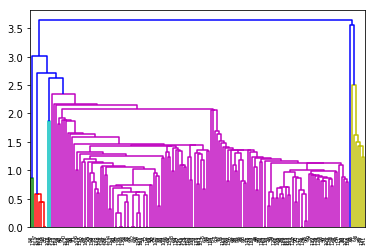

In [14]:
muestra= retail_final.sample(frac=0.01, replace=True, random_state=1)
muestra_variables_resumen=muestra.iloc[:,252:263]

mergings = linkage(muestra_variables_resumen, method="single", metric='euclidean')
dendrogram(mergings)
plt.show()

**Enlace completo <br>**

En la agrupación jerárquica de vinculación completa, la distancia entre dos grupos se define como la distancia más larga entre dos puntos en cada grupo. Por ejemplo, la distancia entre los grupos "r" y "s" a la izquierda es igual a la longitud de la flecha entre sus dos puntos más lejanos.

![](https://www.saedsayad.com/images/Clustering_complete.png)

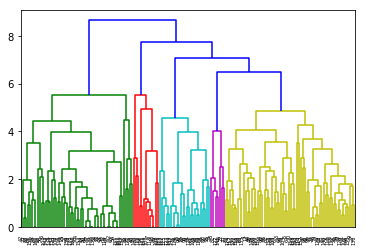

In [15]:
# Complete linkage

mergings = linkage(muestra_variables_resumen, method="complete", metric='euclidean')
dendrogram(mergings)
plt.show()

**Vinculación promedio: <br>**

En el agrupamiento jerárquico de vinculación promedio, la distancia entre dos grupos se define como la distancia promedio entre cada punto de un grupo y cada punto del otro grupo. Por ejemplo, la distancia entre los grupos "r" y "s" a la izquierda es igual a la longitud promedio de cada flecha entre la conexión de los puntos de un grupo con el otro.

![](https://www.saedsayad.com/images/Clustering_average.png)

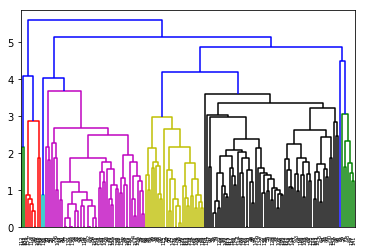

In [16]:
# Average linkage

mergings = linkage(muestra_variables_resumen, method="average", metric='euclidean')
dendrogram(mergings)
plt.show()

### Parámetro metric

metric: str or function, optional

The distance metric to use. The distance function can be ‘braycurtis’, ‘canberra’, ‘chebyshev’, ‘cityblock’, ‘correlation’, ‘cosine’, ‘dice’, ‘euclidean’, ‘hamming’, ‘jaccard’, ‘jensenshannon’, ‘kulsinski’, ‘mahalanobis’, ‘matching’, ‘minkowski’, ‘rogerstanimoto’, ‘russellrao’, ‘seuclidean’, ‘sokalmichener’, ‘sokalsneath’, ‘sqeuclidean’, ‘yule’.

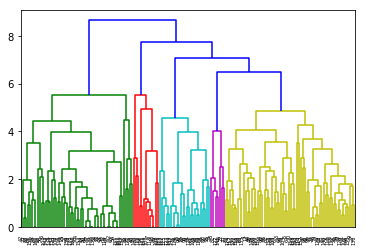

In [17]:
# Métodos y distancias distintas

mergings = linkage(muestra_variables_resumen, method="complete", metric='minkowski')
dendrogram(mergings)
plt.show()

#### Corte del Dendograma basado en cantidad de cluster K

In [18]:
# Determinamos 5 clusters
cluster_labels = cut_tree(mergings, n_clusters=5).reshape(-1, )
muestra['Cluster_Labels'] = cluster_labels
muestra.groupby('Cluster_Labels').size()

Cluster_Labels
0    64
1    55
2    13
3     7
4    25
dtype: int64

In [19]:
# Assign cluster labels

muestra['Cluster_Labels'] = cluster_labels
muestra.head()

,Código o nro. de negocio,Tipo de Negocio o Rubro principal,Ubicación,Movimiento o Tránsito en calle principal,Cantidad de cajas,Cantidad de sucursales,Abierto desde,Abierto hasta,Cantidad Días por Semana,Metros cuadrados salón de ventas,...,ALIMENTOS_PREPARADOS_std,OTROS_ALMACEN_std,JUGOS_INFUSIONES_std,VINOS_std,ALMACEN_std,COSMETICA_ALTA_std,HOGAR_std,LIMPIEZA_std,COSMETICA_COMUN_std,Cluster_Labels
13349,52301629,KIOSCO VENTANA CON INGRESO,CALLE O AVDA. PRINCIPAL,MEDIANAMENTE TRANSITADO,0,0,08:30,22:00,6,6,...,-0.715585,-0.822820,1.532393,-1.342849,-0.216916,0.490602,-0.538585,0.851162,0.325298,0
235,4150916,ALMACEN / DESPENSA / FIAMBRERIA,BARRIO,POCO TRANSITADO,0,0,09:00,22:00,7,8,...,0.581052,-1.064431,0.910017,-0.258785,0.225508,-0.665645,-0.091697,1.145320,0.325298,0
12172,807146960,MAXIKIOSCO / DRUG STORE (S/VENTANA),CALLE O AVDA. PRINCIPAL,MUY TRANSITADO,0,0,08:00,21:00,6,40,...,-0.715585,-1.064431,-1.579484,-1.342849,-1.433583,-0.665645,-0.985472,-1.502099,-1.910016,1
5192,784441361,ALMACEN / DESPENSA / FIAMBRERIA,BARRIO,POCO TRANSITADO,0,0,09:00,22:00,7,15,...,-0.715585,0.143624,-0.334733,0.825279,0.446720,-0.665645,-0.985472,-0.325469,-0.233531,0
16127,1506137306,KIOSCO VENTANA CON INGRESO,BARRIO,POCO TRANSITADO,0,0,08:30,20:00,6,36,...,-0.715585,-1.064431,-0.334733,-1.342849,-1.322977,-0.665645,-0.985472,-0.913784,-0.792359,1


In [20]:
# Contamos la cantidad de casos que quedan en cada grupo

muestra.groupby('Cluster_Labels').size()

Cluster_Labels
0    64
1    55
2    13
3     7
4    25
dtype: int64

In [21]:
# Determinamos 4 clusters
cluster_labels = cut_tree(mergings, n_clusters=4).reshape(-1, )
muestra['Cluster_Labels'] = cluster_labels
muestra.groupby('Cluster_Labels').size()

Cluster_Labels
0    71
1    55
2    13
3    25
dtype: int64

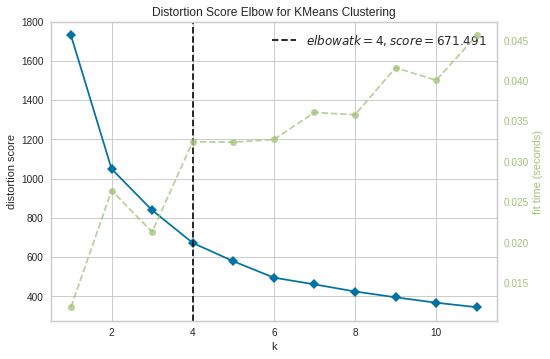

In [22]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

from yellowbrick.cluster import KElbowVisualizer


# Instantiate the clustering model and visualizer
model = KMeans()
visualizer = KElbowVisualizer(model, k=(1,12))

visualizer.fit(muestra_variables_resumen)        # Fit the data to the visualizer
visualizer.show()        # Finalize and render the figure

In [23]:
##agregamos la cantidad de decimales que queremos mostrar
muestra.groupby('Cluster_Labels').mean().round(2)

,Código o nro. de negocio,Cantidad de cajas,Cantidad Días por Semana,Metros cuadrados salón de ventas,Cantidad de Empleados,Cant. de heladeras verticales para bebidas o lácteos,Cantidad Categorías,Alimentos y Bebidas,Aceites,Aceites Sueltos,...,Café instantáneo_std,ALIMENTOS_PREPARADOS_std,OTROS_ALMACEN_std,JUGOS_INFUSIONES_std,VINOS_std,ALMACEN_std,COSMETICA_ALTA_std,HOGAR_std,LIMPIEZA_std,COSMETICA_COMUN_std
Cluster_Labels,,,,,,,,,,,,,,,,,,,,,
0,4.493356e+08,0.03,6.80,25.66,2.20,2.11,60.69,31.35,0.93,0.03,...,0.06,-0.18,0.02,0.64,0.32,0.66,-0.36,-0.22,0.50,0.41
1,6.496271e+08,0.04,6.56,25.27,1.95,2.22,20.67,9.58,0.25,0.00,...,-0.23,-0.57,-0.81,-0.49,-0.75,-0.95,-0.62,-0.94,-1.30,-1.25
2,7.623780e+08,0.00,6.46,38.00,2.38,0.23,26.92,3.77,0.15,0.00,...,-0.30,-0.72,-0.99,-1.63,-1.34,-1.24,1.87,0.91,0.47,0.54
3,6.754527e+08,1.08,6.96,101.68,2.96,6.44,87.40,43.92,1.00,0.00,...,-0.30,1.57,1.28,0.51,0.83,0.90,1.30,1.41,0.90,0.79


In [24]:
##agregamos algunas de las variables específicas a mostrar
muestra.groupby("Cluster_Labels")['Metros cuadrados salón de ventas','Cantidad Categorías'].mean().round(2)

,Metros cuadrados salón de ventas,Cantidad Categorías
Cluster_Labels,,
0,25.66,60.69
1,25.27,20.67
2,38.00,26.92
3,101.68,87.40


In [25]:
##podemos calcular alguna medida en particular como la mediana
muestra.groupby("Cluster_Labels")['Metros cuadrados salón de ventas','Cantidad Categorías'].median().round(2)

,Metros cuadrados salón de ventas,Cantidad Categorías
Cluster_Labels,,
0,24,59
1,20,19
2,25,26
3,56,89


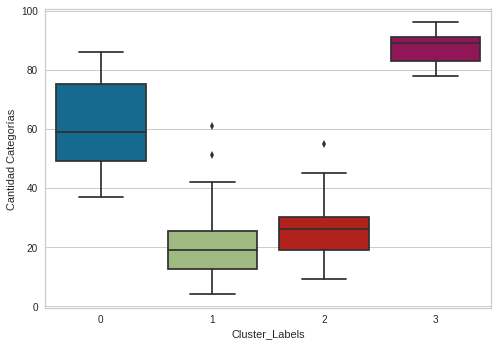

In [26]:
# Plot Cluster Id vs Cantidad de categorías

sns.boxplot(x='Cluster_Labels', y='Cantidad Categorías', data=muestra)

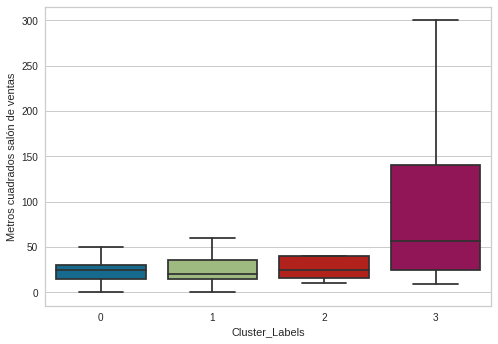

In [27]:
# Plot Cluster Id vs Metros cuadrados salón de ventas

sns.boxplot(x='Cluster_Labels', y='Metros cuadrados salón de ventas', data=muestra, showfliers=False)

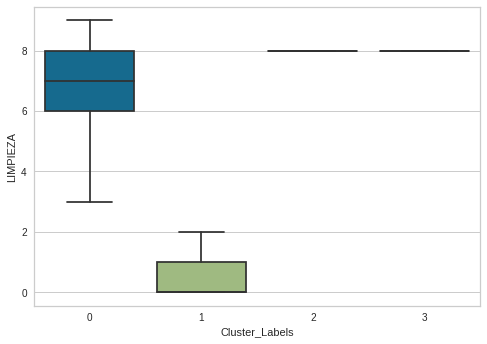

In [28]:
# Plot por productos de Limpieza

sns.boxplot(x='Cluster_Labels', y='LIMPIEZA', data=muestra, showfliers=False)

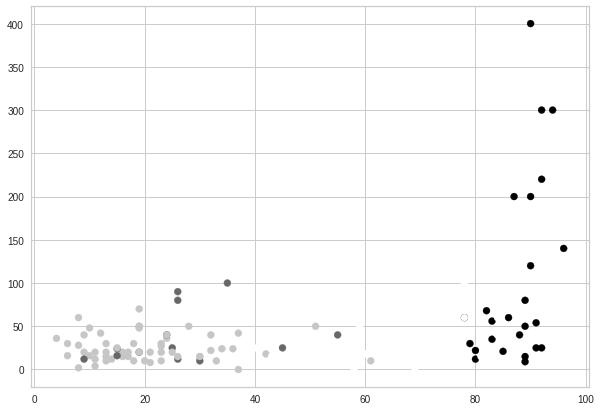

In [29]:


plt.figure(figsize=(10, 7))  
plt.scatter(muestra['Cantidad Categorías'], muestra['Metros cuadrados salón de ventas'], c=muestra.Cluster_Labels)

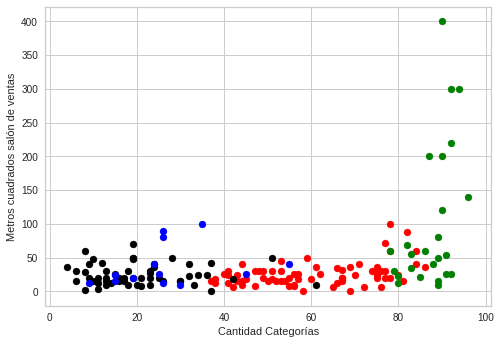

In [30]:
#filtramos por cluster
filtered_label0 = muestra.loc[muestra['Cluster_Labels'] == 0] 
filtered_label1 = muestra.loc[muestra['Cluster_Labels'] == 1]
filtered_label2 = muestra.loc[muestra['Cluster_Labels'] == 2]
filtered_label3 = muestra.loc[muestra['Cluster_Labels'] == 3]
 
#hacemos el gráfico con 
plt.scatter(filtered_label0.loc[:,'Cantidad Categorías'] , filtered_label0.loc[:,'Metros cuadrados salón de ventas'] , color = 'red')
plt.scatter(filtered_label1.loc[:,'Cantidad Categorías'] , filtered_label1.loc[:,'Metros cuadrados salón de ventas']  , color = 'black')
plt.scatter(filtered_label2.loc[:,'Cantidad Categorías'] , filtered_label2.loc[:,'Metros cuadrados salón de ventas']  , color = 'blue')
plt.scatter(filtered_label3.loc[:,'Cantidad Categorías'] , filtered_label3.loc[:,'Metros cuadrados salón de ventas']  , color = 'green')
plt.xlabel("Cantidad Categorías")
plt.ylabel("Metros cuadrados salón de ventas")
plt.show()


In [31]:
## Aplicamos un análisis multivariado de la varianza para entender si los vectores de medias son iguales

from statsmodels.multivariate.manova import MANOVA


maov = MANOVA.from_formula("ALIMENTOS_PREPARADOS + OTROS_ALMACEN + JUGOS_INFUSIONES + VINOS + ALMACEN + COSMETICA_ALTA + HOGAR + LIMPIEZA + COSMETICA_COMUN ~ Cluster_Labels", data=muestra)


print(maov.mv_test())

                  Multivariate linear model
                                                             
-------------------------------------------------------------
       Intercept        Value  Num DF  Den DF  F Value Pr > F
-------------------------------------------------------------
          Wilks' lambda 0.1716 9.0000 154.0000 82.6139 0.0000
         Pillai's trace 0.8284 9.0000 154.0000 82.6139 0.0000
 Hotelling-Lawley trace 4.8281 9.0000 154.0000 82.6139 0.0000
    Roy's greatest root 4.8281 9.0000 154.0000 82.6139 0.0000
-------------------------------------------------------------
                                                             
-------------------------------------------------------------
     Cluster_Labels     Value  Num DF  Den DF  F Value Pr > F
-------------------------------------------------------------
          Wilks' lambda 0.3141 9.0000 154.0000 37.3665 0.0000
         Pillai's trace 0.6859 9.0000 154.0000 37.3665 0.0000
 Hotelling-Lawley trace 2.